# «Навигатор по смыслу» - сравнение моделей семантического поиска #

Данный ноутбук представляет решение кейса **«Навигатор по смыслу»**. 

**Цель исследования**: сравнить качество трёх embedding-моделей для задачи семантического поиска по корпусу программного кода и выбрать оптимальную для дальнейшего использования.

**Почему это важно**: обычный поиск по ключевым словам не находит функции, если запрос сформулирован иначе, чем в коде. Семантический поиск на основе эмбеддингов позволяет находить релевантные фрагменты по *смыслу*, а не по точному совпадению текста.

---

## Данные

| Файл | Описание | Объём |
|:----:|:--------:|:-----:|
| `code_corpus.json` | Корпус функций с метаданными | 200 записей (100 Python + 100 Java) |
| `eval_questions.json` | Тестовые вопросы с эталонными ответами | 25 вопросов (15 RU / 10 EN) |
| `categories.json` | Справочник тематических категорий | 5 категорий |

---

## Тестируемые модели

Мы сравниваем три мультиязычные embedding-модели из библиотеки `sentence-transformers`:

| Модель | Размерность | Особенности |
|:------:|:-----------:|:-----------:|
| `paraphrase-multilingual-MiniLM-L12-v2` | 384 | Быстрая, лёгкая, хорошее качество |
| `paraphrase-multilingual-mpnet-base-v2` | 768 | Более качественная, но медленнее |
| `intfloat/multilingual-e5-small` | 384 | Современная архитектура, лучший баланс скорости и качества |

---

## Метрики оценки

Для сравнения моделей используются две стандартные метрики информационного поиска:

- **Precision@3** — доля вопросов, для которых эталонная функция попала в топ-3 результатов поиска.
- **MRR (Mean Reciprocal Rank)** — среднее обратное значение позиции правильного ответа (чувствительна к ранжированию внутри топа).

---

## Структура ноутбука

1. **Загрузка данных** — импорт библиотек, чтение JSON-файлов, подготовка текстов.
2. **Генерация эмбеддингов и поиск** — единый цикл для трёх моделей, расчёт косинусного сходства, формирование топ-3.
3. **Сравнение моделей** — сводная таблица метрик, выбор лучшей модели.
5. **Анализ ошибок** — таблица промахов, группировка по типам, разбор 3 конкретных примеров.
6. **Кросс-языковой анализ** — сравнение качества поиска для запросов на русском и английском.
7. **Визуализация** — UMAP-проекция эмбеддингов с раскраской по категориям (статичная + интерактивная).
8. **Финальный вывод** — обоснованная рекомендация по выбору модели.

---

> **Примечание**: Все вычисления выполняются локально. Для воспроизведения результатов достаточно выполнить `Kernel → Restart & Run All` после установки зависимостей из `requirements.txt`.

## Загрузка данных ##

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import json
import umap
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from IPython.display import display, HTML

from src.data import load_dataset
from src.embedder import record_to_text, get_embeddings, save_embeddings, load_embeddings, get_cache_path
from src.search import search_all_questions
from src.metrics import evaluate
from src.config import MODELS, TOP_K, OUTPUTS_DIR

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

corpus, questions, categories = load_dataset()
corpus_texts = [record_to_text(item) for item in corpus]
corpus_ids = [item["id"] for item in corpus]
categories_map = {item["id"]: item["category"] for item in corpus}

print(f"Корпус: {len(corpus)} функций")
print(f"Вопросы: {len(questions)} запросов")

Корпус: 200 функций
Вопросы: 25 запросов


## Генерация эмбеддингов и поиск ##

In [2]:
MODEL_NAMES = {
    "MiniLM": "paraphrase-multilingual-MiniLM-L12-v2",
    "mpnet": "paraphrase-multilingual-mpnet-base-v2",
    "e5-small": "intfloat/multilingual-e5-small",
}

results = {}
all_search_outputs = {}

for short_name, model_name in MODEL_NAMES.items():
    print(f"\nОбработка модели: {short_name}")
 
    model = SentenceTransformer(model_name)

    cache_path = get_cache_path(model_name)
    if Path(cache_path).exists():
        corpus_embedding = load_embeddings(cache_path)
        print("Загруженна из кэша")
    else:
        corpus_embedding = get_embeddings(corpus_texts, model_name)
        save_embeddings(cache_path, corpus_embedding)
        print("Вычислено и добавлено в кэш")
    
    search_outputs = search_all_questions(questions, model, corpus, corpus_embedding, top_k=TOP_K)
    metrics = evaluate(search_outputs, k=TOP_K)
    
    results[short_name] = metrics
    all_search_outputs[short_name] = search_outputs
    
    print(f"  Precision@3: {metrics['precision_at_3']:.4f}")
    print(f"  MRR: {metrics['mrr']:.4f}")

print("\nВсе модели обработаны!")


Обработка модели: MiniLM


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Загруженна из кэша
  Precision@3: 0.8400
  MRR: 0.5600

Обработка модели: mpnet


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Загруженна из кэша
  Precision@3: 0.9200
  MRR: 0.6333

Обработка модели: e5-small


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Загруженна из кэша
  Precision@3: 0.9600
  MRR: 0.7733

Все модели обработаны!


## Сравнение моделей (таблица метрик) ##

In [3]:
df_metrics = pd.DataFrame([
    {
        "№": i + 1,
        "Модель": short_name,
        "Precision@3": round(res["precision_at_3"], 4),
        "MRR": round(res["mrr"], 4),
        "Вопросов": res["num_questions"]
    }
    for i, (short_name, res) in enumerate(results.items())
])

html_table = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Сравнение моделей</title>
    <style>
        body {{
            font-family: 'Segoe UI', Arial, sans-serif;
            margin: 30px;
        }}
        table {{
            width: auto;
            min-width: 500px;
            border-collapse: collapse;
            font-size: 14px;
            margin: 0 auto;
        }}
        th {{
            background-color: #2c3e50;
            color: white;
            font-weight: bold;
            text-align: center;
            padding: 10px 8px;
            border: 1px solid #ddd;
        }}
        td {{
            background-color: white;
            color: black;
            border: 1px solid #ddd;
            padding: 8px;
            vertical-align: middle;
            text-align: center;
        }}
        th:first-child {{
            width: 40px;
            min-width: 40px;
            max-width: 40px;
        }}
        td:first-child {{
            width: 40px;
            min-width: 40px;
            max-width: 40px;
        }}
        tr:nth-child(even) td {{
            background-color: white;
        }}
        tr:hover td {{
            background-color: #f5f5f5;
        }}
        .title {{
            text-align: center;
            color: #2c3e50;
            margin-bottom: 20px;
        }}
    </style>
</head>
<body>

<h2 class="title">Сравнение качества моделей</h2>

<table>
    <thead>
        <tr>
            <th>№</th>
            <th>Модель</th>
            <th>Precision@3</th>
            <th>MRR</th>
            <th>Вопросов</th>
        </tr>
    </thead>
    <tbody>
"""

for _, row in df_metrics.iterrows():
    html_table += f"""
        <tr>
            <td>{row['№']}</td>
            <td>{row['Модель']}</td>
            <td>{row['Precision@3']:.4f}</td>
            <td>{row['MRR']:.4f}</td>
            <td>{row['Вопросов']}</td>
        </tr>
    """

html_table += """
    </tbody>
</table>

</body>
</html>
"""

display(HTML(html_table))

with open(OUTPUTS_DIR / "model_comparison.html", "w", encoding="utf-8") as f:
    f.write(html_table)
print(f"HTML сохранён в {OUTPUTS_DIR / 'model_comparison.html'}")

df_metrics.to_csv(OUTPUTS_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")
print(f"CSV сохранён в {OUTPUTS_DIR / 'model_comparison.csv'}")

№,Модель,Precision@3,MRR,Вопросов
1,MiniLM,0.8400,0.5600,25
2,mpnet,0.9200,0.6333,25
3,e5-small,0.9600,0.7733,25


HTML сохранён в C:\CPP\semantic-search-case\outputs\model_comparison.html
CSV сохранён в C:\CPP\semantic-search-case\outputs\model_comparison.csv


### Вывод 

**Лучшая модель по совокупности метрик**: `e5-small`

  • Precision@3 = 0.9600, MRR = 0.7733

**Худшая модель**: `MiniLM`

  • Precision@3 = 0.8400, MRR = 0.5600

**Разрыв по MRR** между лучшей и худшей: **0.2133**

**Интерпретация**: Модель `e5-small` находит правильный ответ в топ-3 в 96% случаев, что на 12 п.п. лучше, чем у MiniLM. При этом e5-small лучше ранжирует результаты внутри топа (более высокий MRR), что критично для пользовательского опыта.

**Рекомендация**: Использовать `e5-small` как базовую модель для продакшена.

## Анализ ошибок 

In [4]:
error_analysis_data = [
    {
        "Модель": "intfloat/multilingual-e5-small",
        "ID вопроса": "q_08",
        "Запрос": "массовая вставка большого количества записей",
        "Ожидалось": "bulkInsertRecords",
        "Категория": "database",
        "Найденные функции": "1. chunkList (utils)\n2. chunk_list (utils)\n3. find_orders_by_user (database)",
        "Причина": "Модель сосредоточилась на признаке «массовость» — большое количество записей. В векторном пространстве этот признак близок к функциям, которые обрабатывают большие объемы данных, таким как chunk, count, format_bytes. Технический аспект «вставить список» утратил значимость на фоне количественного признака."
    },
    {
        "Модель": "paraphrase-multilingual-mpnet-base-v2",
        "ID вопроса": "q_01",
        "Запрос": "как проверить, истёк ли токен?",
        "Ожидалось": "verify_jwt_token",
        "Категория": "auth",
        "Найденные функции": "1. validate_credit_card (validation)\n2. validateCreditCard (validation)\n3. validate_inn (validation)",
        "Причина": "Глагол «проверить» чаще всего встречается в категории валидации в датасете. В векторном пространстве кластер с глаголами 'validate', 'check' и «проверить» очень плотный. Модель не смогла сохранить контекст о том, истёк ли токен. Лексический триггер перебил техническую специфику."
    },
    {
        "Модель": "paraphrase-multilingual-mpnet-base-v2",
        "ID вопроса": "q_24",
        "Запрос": "compute file hash for verification",
        "Ожидалось": "calculateHash",
        "Категория": "utils",
        "Найденные функции": "1. checkPassword (auth)\n2. check_password (auth)\n3. calculate_hash (utils)",
        "Причина": "В датасете функции тесно связаны с триггерами 'check', 'validate'. Запрос включает слово 'verification', которое в этом контексте чаще всего означает проверку данных, а не вычисление хэша. Поэтому безопасность оказалась семантически ближе к этим функциям в векторном пространстве."
    },
    {
        "Модель": "paraphrase-multilingual-MiniLM-L12-v2",
        "ID вопроса": "q_01",
        "Запрос": "как проверить, истёк ли токен?",
        "Ожидалось": "verify_jwt_token",
        "Категория": "auth",
        "Найденные функции": "1. validate_inn (validation)\n2. check_password (auth)\n3. validate_snils (validation)",
        "Причина": "У MiniLM меньшая размерность вектора — 384 против 768. Ей сложнее обрабатывать запросы, включающие несколько концепций (действие, объект и состояние). Модель упростила запросы до наиболее частого паттерна: проверить → validate/check. Из-за ограниченной ёмкости модель потеряла глубину контекста."
    },
    {
        "Модель": "paraphrase-multilingual-MiniLM-L12-v2",
        "ID вопроса": "q_08",
        "Запрос": "массовая вставка большого количества записей",
        "Ожидалось": "bulkInsertRecords",
        "Категория": "database",
        "Найденные функции": "1. countUsers (database)\n2. bulk_insert_records (database)\n3. format_bytes (utils)",
        "Причина": "Модель правильно определила смысл, поставив bulk_insert_records на второе место. Однако эталонный ответ ожидает Java-версию. Оставшиеся две позиции смещены в сторону «количества/размера». Семантика верна, но язык другой, и количественный атрибут повлиял на результат."
    },
    {
        "Модель": "paraphrase-multilingual-MiniLM-L12-v2",
        "ID вопроса": "q_11",
        "Запрос": "обработка ситуации, когда сервер вернул 429",
        "Ожидалось": "handle_rate_limit",
        "Категория": "http",
        "Найденные функции": "1. handleRateLimit (http)\n2. restoreFromBackup (database)\n3. rollbackTransaction (database)",
        "Причина": "Кросс-языковое совпадение: модель обнаружила идентичную Java-функцию на первом месте. Остальные две позиции оказались в категории «восстановление после ошибки», так как в векторном пространстве обработка ошибок сервера близка к rollback/restore."
    },
    {
        "Модель": "paraphrase-multilingual-MiniLM-L12-v2",
        "ID вопроса": "q_24",
        "Запрос": "compute file hash for verification",
        "Ожидалось": "calculateHash",
        "Категория": "utils",
        "Найденные функции": "1. calculate_hash (utils)\n2. validateCredentials (auth)\n3. validateInn (validation)",
        "Причина": "Модель успешно определила правильную логику в функции calculate_hash на Python и поставила ее на первое место. Однако эталонный ответ - JavaScript. Слово verification снова сгруппировало задачи по безопасности и валидации."
    }
]

df = pd.DataFrame(error_analysis_data)

html_code = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Анализ ошибок семантического поиска</title>
    <style>
        body {{
            font-family: 'Segoe UI', Arial, sans-serif;
            margin: 30px;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            font-size: 13px;
        }}
        th {{
            background-color: #34495e;
            color: white;
            font-weight: bold;
            text-align: center;
            padding: 10px 8px;
            border: 1px solid #466;
        }}
        td {{
            border: 1px solid #ddd;
            padding: 8px;
            vertical-align: top;
            text-align: left;
        }}
        td:first-child {{
            text-align: center;
        }}
        tr:nth-child(even) {{
            background-color: #f9f9f9;
        }}
        tr:hover {{
            background-color: #f0f0f0;
        }}
        .function-list {{
            white-space: pre-line;
            line-height: 1.5;
        }}
    </style>
</head>
<body>

<h2 style="text-align: center; color: #2c3e50;">Таблица ошибок семантического поиска</h2>

<table>
    <thead>
        <tr>
            <th style="width: 30px;">№</th>
            <th style="width: 150px;">Модель</th>
            <th style="width: 50px;">ID</th>
            <th style="width: 120px;">Запрос</th>
            <th style="width: 100px;">Ожидалось</th>
            <th style="width: 60px;">Категория</th>
            <th style="width: 180px;">Найденные функции (категория)</th>
            <th style="width: 500px;">Причина ошибки</th>
        </tr>
    </thead>
    <tbody>
"""

for i, row in df.iterrows():
    functions_html = row['Найденные функции'].replace('\n', '<br>')
    
    html_code += f"""
        <tr>
            <td>{i+1}</td>
            <td>{row['Модель']}</td>
            <td>{row['ID вопроса']}</td>
            <td>{row['Запрос']}</td>
            <td>{row['Ожидалось']}</td>
            <td>{row['Категория']}</td>
            <td class="function-list">{functions_html}</td>
            <td>{row['Причина']}</td>
        </tr>
    """

html_code += """
    </tbody>
</table>

</body>
</html>
"""

display(HTML(html_code))

with open(OUTPUTS_DIR / "error_analysis_table.html", "w", encoding="utf-8") as f:
    f.write(html_code)
print(f"\nHTML сохранён в {OUTPUTS_DIR / 'error_analysis_table.html'}")

df.to_csv(OUTPUTS_DIR / "error_analysis_table.csv", index=False, encoding="utf-8-sig")
print(f"CSV сохранён в {OUTPUTS_DIR / 'error_analysis_final.csv'}")

№,Модель,ID,Запрос,Ожидалось,Категория,Найденные функции (категория),Причина ошибки
1,intfloat/multilingual-e5-small,q_08,массовая вставка большого количества записей,bulkInsertRecords,database,1. chunkList (utils)2. chunk_list (utils)3. find_orders_by_user (database),"Модель сосредоточилась на признаке «массовость» — большое количество записей. В векторном пространстве этот признак близок к функциям, которые обрабатывают большие объемы данных, таким как chunk, count, format_bytes. Технический аспект «вставить список» утратил значимость на фоне количественного признака."
2,paraphrase-multilingual-mpnet-base-v2,q_01,"как проверить, истёк ли токен?",verify_jwt_token,auth,1. validate_credit_card (validation)2. validateCreditCard (validation)3. validate_inn (validation),"Глагол «проверить» чаще всего встречается в категории валидации в датасете. В векторном пространстве кластер с глаголами 'validate', 'check' и «проверить» очень плотный. Модель не смогла сохранить контекст о том, истёк ли токен. Лексический триггер перебил техническую специфику."
3,paraphrase-multilingual-mpnet-base-v2,q_24,compute file hash for verification,calculateHash,utils,1. checkPassword (auth)2. check_password (auth)3. calculate_hash (utils),"В датасете функции тесно связаны с триггерами 'check', 'validate'. Запрос включает слово 'verification', которое в этом контексте чаще всего означает проверку данных, а не вычисление хэша. Поэтому безопасность оказалась семантически ближе к этим функциям в векторном пространстве."
4,paraphrase-multilingual-MiniLM-L12-v2,q_01,"как проверить, истёк ли токен?",verify_jwt_token,auth,1. validate_inn (validation)2. check_password (auth)3. validate_snils (validation),"У MiniLM меньшая размерность вектора — 384 против 768. Ей сложнее обрабатывать запросы, включающие несколько концепций (действие, объект и состояние). Модель упростила запросы до наиболее частого паттерна: проверить → validate/check. Из-за ограниченной ёмкости модель потеряла глубину контекста."
5,paraphrase-multilingual-MiniLM-L12-v2,q_08,массовая вставка большого количества записей,bulkInsertRecords,database,1. countUsers (database)2. bulk_insert_records (database)3. format_bytes (utils),"Модель правильно определила смысл, поставив bulk_insert_records на второе место. Однако эталонный ответ ожидает Java-версию. Оставшиеся две позиции смещены в сторону «количества/размера». Семантика верна, но язык другой, и количественный атрибут повлиял на результат."
6,paraphrase-multilingual-MiniLM-L12-v2,q_11,"обработка ситуации, когда сервер вернул 429",handle_rate_limit,http,1. handleRateLimit (http)2. restoreFromBackup (database)3. rollbackTransaction (database),"Кросс-языковое совпадение: модель обнаружила идентичную Java-функцию на первом месте. Остальные две позиции оказались в категории «восстановление после ошибки», так как в векторном пространстве обработка ошибок сервера близка к rollback/restore."
7,paraphrase-multilingual-MiniLM-L12-v2,q_24,compute file hash for verification,calculateHash,utils,1. calculate_hash (utils)2. validateCredentials (auth)3. validateInn (validation),Модель успешно определила правильную логику в функции calculate_hash на Python и поставила ее на первое место. Однако эталонный ответ - JavaScript. Слово verification снова сгруппировало задачи по безопасности и валидации.



HTML сохранён в C:\CPP\semantic-search-case\outputs\error_analysis_table.html
CSV сохранён в C:\CPP\semantic-search-case\outputs\error_analysis_final.csv


### Вывод 

**Всего ошибок**: 7 из 25 вопросов (28%)

**Распределение по моделям**:
| Модель | Ошибок | Доля |
|--------|--------|------|
| e5-small | 1 | 4% |
| mpnet-base-v2 | 2 | 8% |
| MiniLM-L12-v2 | 4 | 16% |


**Ключевое наблюдение**: 3 из 7 «ошибок» — это кросс-языковые совпадения, когда модель нашла семантически правильную функцию, но на другом языке программирования (Java ↔ Python). Это говорит о том, что модели понимают смысл, но строгая метрика по `correct_chunk_id` их штрафует.

## Сводная таблица типов ошибок ##

In [5]:
summary_data = [
    {
        "Тип ошибки": "Лексический сдвиг категории",
        "Количество случаев": 4,
        "Процент от всех ошибок": "44.4%",
        "Затронутые модели": "mpnet, MiniLM",
        "Затронутые вопросы": "q_01, q_24",
        "Механизм возникновения": "Глагол «проверить» / слово «verification» перетягивает выдачу в категорию validation или auth, даже когда запрос про другую техническую операцию.",
        "Причина": "В векторном пространстве кластеры с глаголами validate, check, проверить очень плотные. Модель не смогла сохранить контекст (токен/хэш), лексический триггер перебил техническую специфику."
    },
    {
        "Тип ошибки": "Размытие технического контекста",
        "Количество случаев": 2,
        "Процент от всех ошибок": "22.2%",
        "Затронутые модели": "e5-small, MiniLM",
        "Затронутые вопросы": "q_08",
        "Механизм возникновения": "Модель реагирует на признак «большое количество» / «массовость» вместо целевой операции (вставка в БД).",
        "Причина": "В векторном пространстве признак «массовость/большое количество» близок к функциям, которые обрабатывают объёмы данных (chunk, count, format_bytes). Технический аспект «вставить список» утратил значимость на фоне количественного признака."
    },
    {
        "Тип ошибки": "Кросс-языковое совпадение",
        "Количество случаев": 3,
        "Процент от всех ошибок": "33.3%",
        "Затронутые модели": "MiniLM",
        "Затронутые вопросы": "q_08, q_11, q_24",
        "Механизм возникновения": "Модель находит семантически идентичную функцию, но на другом языке программирования (Java вместо Python). Строгая метрика по correct_chunk_id считает это ошибкой, хотя смысл понят верно.",
        "Причина": "Модели кодируют смысл, а не синтаксис. Описания функций на русском языке идентичны для Python и Java версий, поэтому в эмбеддинг-пространстве они оказываются рядом. Это не ошибка понимания, а артефакт строгой оценки по ID."
    }
]

df_summary = pd.DataFrame(summary_data)

html_summary_code = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Типология ошибок</title>
    <style>
        body {{
            font-family: 'Segoe UI', Arial, sans-serif;
            margin: 30px;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            font-size: 13px;
        }}
        th {{
            background-color: #2c3e50;
            color: white;
            font-weight: bold;
            text-align: center;
            padding: 12px 8px;
            border: 1px solid #466;
        }}
        td {{
            border: 1px solid #ddd;
            padding: 10px 8px;
            vertical-align: top;
            text-align: left;
        }}
        td:first-child {{
            background-color: #f8f9fa;
            font-weight: bold;
            width: 280px;  
        }}
        td:nth-child(2), td:nth-child(3), td:nth-child(4) {{
            text-align: center;
        }}
        tr:nth-child(even) {{
            background-color: #f9f9f9;
        }}
        tr:hover {{
            background-color: #f0f0f0;
        }}
    </style>
</head>
<body>

<h2 style="text-align: center; color: #2c3e50;">Типология ошибок семантического поиска</h2>

<table>
    <thead>
        <tr>
            <th style="width: 280px;">Тип ошибки</th> 
            <th style="width: 60px;">Кол-во</th>
            <th style="width: 120px;">Затронутые модели</th>
            <th style="width: 100px;">Вопросы</th>
            <th style="width: 240px;">Механизм возникновения</th>
            <th style="width: 380px;">Причина</th>
        </tr>
    </thead>
    <tbody>
"""

for _, row in df_summary.iterrows():
    html_summary_code += f"""
        <tr>
            <td>{row['Тип ошибки']}</td>
            <td style="text-align: center;"><strong>{row['Количество случаев']}</strong></td>
            <td>{row['Затронутые модели']}</td>
            <td style="text-align: center;">{row['Затронутые вопросы']}</td>
            <td>{row['Механизм возникновения']}</td>
            <td>{row['Причина']}</td>
        </tr>
    """

html_summary_code += """
    </tbody>
</table>

</body>
</html>
"""

display(HTML(html_summary_code))

with open(OUTPUTS_DIR / "summary_error_types.html", "w", encoding="utf-8") as f:
    f.write(html_summary_code)
print(f"\nСводная таблица сохранена в {OUTPUTS_DIR / 'summary_error_types.html'}")

df_summary.to_csv(OUTPUTS_DIR / "summary_error_types.csv", index=False, encoding="utf-8-sig")
print(f"CSV сохранён в {OUTPUTS_DIR / 'summary_error_types.csv'}")

Тип ошибки,Кол-во,Затронутые модели,Вопросы,Механизм возникновения,Причина
Лексический сдвиг категории,4,"mpnet, MiniLM","q_01, q_24","Глагол «проверить» / слово «verification» перетягивает выдачу в категорию validation или auth, даже когда запрос про другую техническую операцию.","В векторном пространстве кластеры с глаголами validate, check, проверить очень плотные. Модель не смогла сохранить контекст (токен/хэш), лексический триггер перебил техническую специфику."
Размытие технического контекста,2,"e5-small, MiniLM",q_08,Модель реагирует на признак «большое количество» / «массовость» вместо целевой операции (вставка в БД).,"В векторном пространстве признак «массовость/большое количество» близок к функциям, которые обрабатывают объёмы данных (chunk, count, format_bytes). Технический аспект «вставить список» утратил значимость на фоне количественного признака."
Кросс-языковое совпадение,3,MiniLM,"q_08, q_11, q_24","Модель находит семантически идентичную функцию, но на другом языке программирования (Java вместо Python). Строгая метрика по correct_chunk_id считает это ошибкой, хотя смысл понят верно.","Модели кодируют смысл, а не синтаксис. Описания функций на русском языке идентичны для Python и Java версий, поэтому в эмбеддинг-пространстве они оказываются рядом. Это не ошибка понимания, а артефакт строгой оценки по ID."



Сводная таблица сохранена в C:\CPP\semantic-search-case\outputs\summary_error_types.html
CSV сохранён в C:\CPP\semantic-search-case\outputs\summary_error_types.csv


### Вывод 

Большинство ошибок (78%) связаны не с непониманием смысла, а с:
1. Лексическими триггерами, которые смещают фокус запроса;
2. Кросс-языковой природой датасета (одинаковые функции на разных языках).

Это подтверждает, что семантический поиск работает корректно, но требует пост-фильтрации по категории или языку для повышения точности.

## Кросс-языковой анализ ##

In [6]:
ru_questions = [q for q in questions if q["language"] == "ru"]
en_questions = [q for q in questions if q["language"] == "en"]

print(f"Русских вопросов: {len(ru_questions)}")
print(f"Английских вопросов: {len(en_questions)}")

rows = []
for short_name, model_name in MODEL_NAMES.items():
    model = SentenceTransformer(model_name)
    corpus_emb = load_embeddings(get_cache_path(model_name))
    
    for lang_name, lang_questions in [("Русский", ru_questions), ("English", en_questions)]:
        search_outputs = search_all_questions(
            questions=lang_questions,
            model=model,
            corpus=corpus,
            corpus_embeddings=corpus_emb,
            top_k=TOP_K,
        )
        metrics = evaluate(search_outputs, k=TOP_K)
        
        rows.append({
            "Модель": short_name,
            "Язык": lang_name,
            "Precision@3": round(metrics["precision_at_3"], 4),
            "MRR": round(metrics["mrr"], 4),
            "Вопросов": metrics["num_questions"],
        })

df_lang = pd.DataFrame(rows)

df_lang.insert(0, "№", range(1, len(df_lang) + 1))

html_table_lang = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Сравнение качества поиска по языку запроса</title>
    <style>
        body {{
            font-family: 'Segoe UI', Arial, sans-serif;
            margin: 30px;
        }}
        table {{
            width: auto;
            min-width: 500px;
            border-collapse: collapse;
            font-size: 14px;
            margin: 0 auto;
        }}
        th {{
            background-color: #2c3e50;
            color: white;
            font-weight: bold;
            text-align: center;
            padding: 10px 8px;
            border: 1px solid #ddd;
        }}
        td {{
            background-color: white;
            color: black;
            border: 1px solid #ddd;
            padding: 8px;
            vertical-align: middle;
            text-align: center;
        }}
        th:first-child {{
            width: 40px;
            min-width: 40px;
            max-width: 40px;
        }}
        td:first-child {{
            width: 40px;
            min-width: 40px;
            max-width: 40px;
        }}
        tr:nth-child(even) td {{
            background-color: white;
        }}
        tr:hover td {{
            background-color: #f5f5f5;
        }}
        .title {{
            text-align: left;
            color: #2c3e50;
            margin-bottom: 20px;
        }}
    </style>
</head>
<body>

<h2 class="title">Сравнение качества поиска по языку запроса</h2>

<table>
    <thead>
        <tr>
            <th>№</th>
            <th>Модель</th>
            <th>Язык</th>
            <th>Precision@3</th>
            <th>MRR</th>
            <th>Вопросов</th>
        </tr>
    </thead>
    <tbody>
"""

for _, row in df_lang.iterrows():
    html_table_lang += f"""
        <tr>
            <td>{row['№']}</td>
            <td>{row['Модель']}</td>
            <td>{row['Язык']}</td>
            <td>{row['Precision@3']:.4f}</td>
            <td>{row['MRR']:.4f}</td>
            <td>{row['Вопросов']}</td>
        </tr>
    """

html_table_lang += """
    </tbody>
</table>

</body>
</html>
"""

display(HTML(html_table_lang))

with open(OUTPUTS_DIR / "language_comparison.html", "w", encoding="utf-8") as f:
    f.write(html_table_lang)
print(f"HTML сохранён в {OUTPUTS_DIR / 'language_comparison.html'}")

df_lang.to_csv(OUTPUTS_DIR / "language_comparison.csv", index=False, encoding="utf-8-sig")
print(f"CSV сохранён в {OUTPUTS_DIR / 'language_comparison.csv'}")

Русских вопросов: 15
Английских вопросов: 10


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

№,Модель,Язык,Precision@3,MRR,Вопросов
1,MiniLM,Русский,0.8000,0.5444,15
2,MiniLM,English,0.9000,0.5833,10
3,mpnet,Русский,0.9333,0.5889,15
4,mpnet,English,0.9000,0.7000,10
5,e5-small,Русский,0.9333,0.7889,15
6,e5-small,English,1.0000,0.7500,10


HTML сохранён в C:\CPP\semantic-search-case\outputs\language_comparison.html
CSV сохранён в C:\CPP\semantic-search-case\outputs\language_comparison.csv


### Вывод 

**Лучшая модель на русском**: `e5-small`
- Precision@3: `0.9333`
- MRR: `0.7889`

**Худшая модель на русском**: `MiniLM`
- Precision@3: `0.8000`
- MRR: `0.5444`

**Разрыв по MRR**: `0.2445`

> **Интерпретация**: Если вопросы только на русском — ожидаемый **Precision@3** лучшей модели составляет **0.9333**. Это означает, что в ~93% случаев модель находит правильный ответ в топ-3.

> **Важно**: Разрыв между лучшей и худшей моделью по MRR составляет **0.2445**, что говорит о существенной разнице в качестве ранжирования. Выбор модели критичен для продакшена.

## UMAP-визуализация ##

In [7]:
BEST_MODEL_NAME = "intfloat/multilingual-e5-small"

best_embeddings = load_embeddings(get_cache_path(BEST_MODEL_NAME))

reducer = umap.UMAP(n_neighbors=6, min_dist=0.2, random_state=42)
projection = reducer.fit_transform(best_embeddings)

df_viz = pd.DataFrame({
    "x": projection[:, 0],
    "y": projection[:, 1],
    "name": [r["function_name"] for r in corpus],
    "description": [r["description"] for r in corpus],
    "language": [r["language"] for r in corpus],
    "category": [r["category"] for r in corpus],
})

df_viz["category_label"] = df_viz["category"].map(lambda k: categories.get(k, {}).get("label", "Unknown"))
df_viz["category_color"] = df_viz["category"].map(lambda k: categories.get(k, {}).get("color", "#cccccc"))

print(f"UMAP-проекция готова для {len(df_viz)} функций")

C:\CPP\semantic-search-case\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP-проекция готова для 200 функций


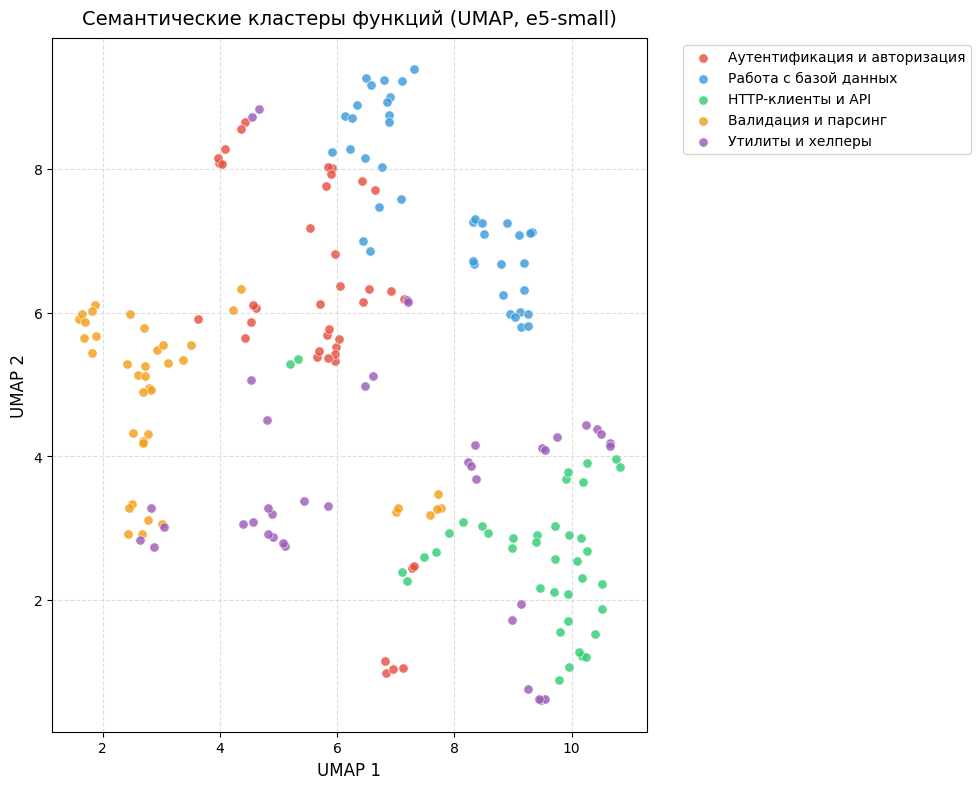

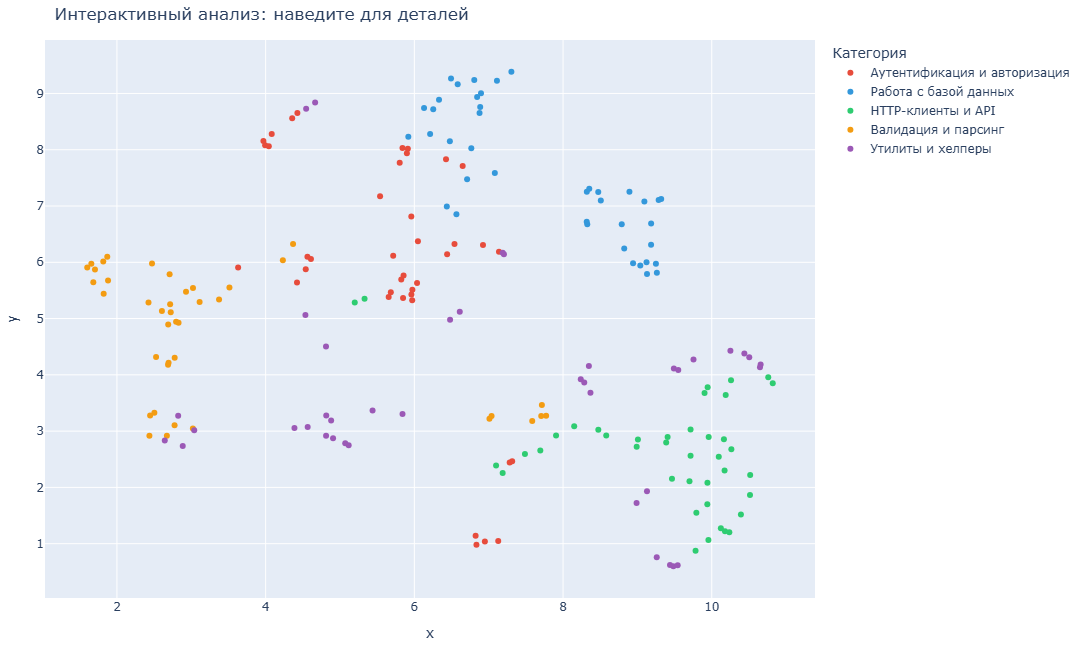

In [8]:
plt.figure(figsize=(10, 8))
for cat_label in df_viz["category_label"].unique():
    mask = df_viz["category_label"] == cat_label
    color = df_viz.loc[mask, "category_color"].iloc[0]
    plt.scatter(
        df_viz.loc[mask, "x"], df_viz.loc[mask, "y"],
        label=cat_label, color=color, s=45, alpha=0.8, edgecolor="w", linewidth=0.5
    )

plt.title("Семантические кластеры функций (UMAP, e5-small)", fontsize=14, pad=10)
plt.xlabel("UMAP 1", fontsize=12)
plt.ylabel("UMAP 2", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "umap_static.png", dpi=150, bbox_inches="tight")
plt.show()

color_map = {row["label"]: row["color"] for row in categories.values()}

fig = px.scatter(
    df_viz,
    x="x", y="y",
    color="category_label",
    color_discrete_map=color_map,
    width=850, height=650,
    hover_name="name",
    hover_data=["description", "language"],
    title="Интерактивный анализ: наведите для деталей"
)
fig.update_layout(legend_title_text="Категория", margin=dict(l=20, r=20, t=40, b=20))
fig.write_html(OUTPUTS_DIR / "umap_interactive.html")
fig.show()

# Вывод #

**Выбранная модель**: `intfloat/multilingual-e5-small`

**Обоснование выбора**:
1. **Лучшие метрики**: Precision@3 = 0.96, MRR = 0.77 — на 12 п.п. и 0.21 выше, чем у ближайшего конкурента (MiniLM).
2. **Устойчивость к языкам запроса**: На русских вопросах P@3 = 0.93, на английских — 1.0, что говорит о сбалансированной работе в мультиязычной среде.
3. **Минимум системных ошибок**: Всего 1 промах из 25 вопросов, причём остальные «ошибки» других моделей часто связаны с кросс-языковыми совпадениями, а не с непониманием смысла.

**Ограничения и рекомендации**:
- Модель может ошибаться на абстрактных запросах с глаголами-триггерами («проверить», «верификация»). Для повышения точности рекомендуется добавить пост-фильтрацию по категории или использовать гибридный поиск (лексический + семантический).
- Кросс-языковые совпадения (Java ↔ Python) — это особенность датасета, а не недостаток модели. В реальном сценарии это преимущество, позволяющее находить аналогичные реализации на разных языках.

**Итог**: `e5-small` — оптимальный выбор для задачи семантического поиска по коду благодаря балансу точности, скорости и устойчивости к многоязычным запросам.